## Agents and tools -> using LCEL 

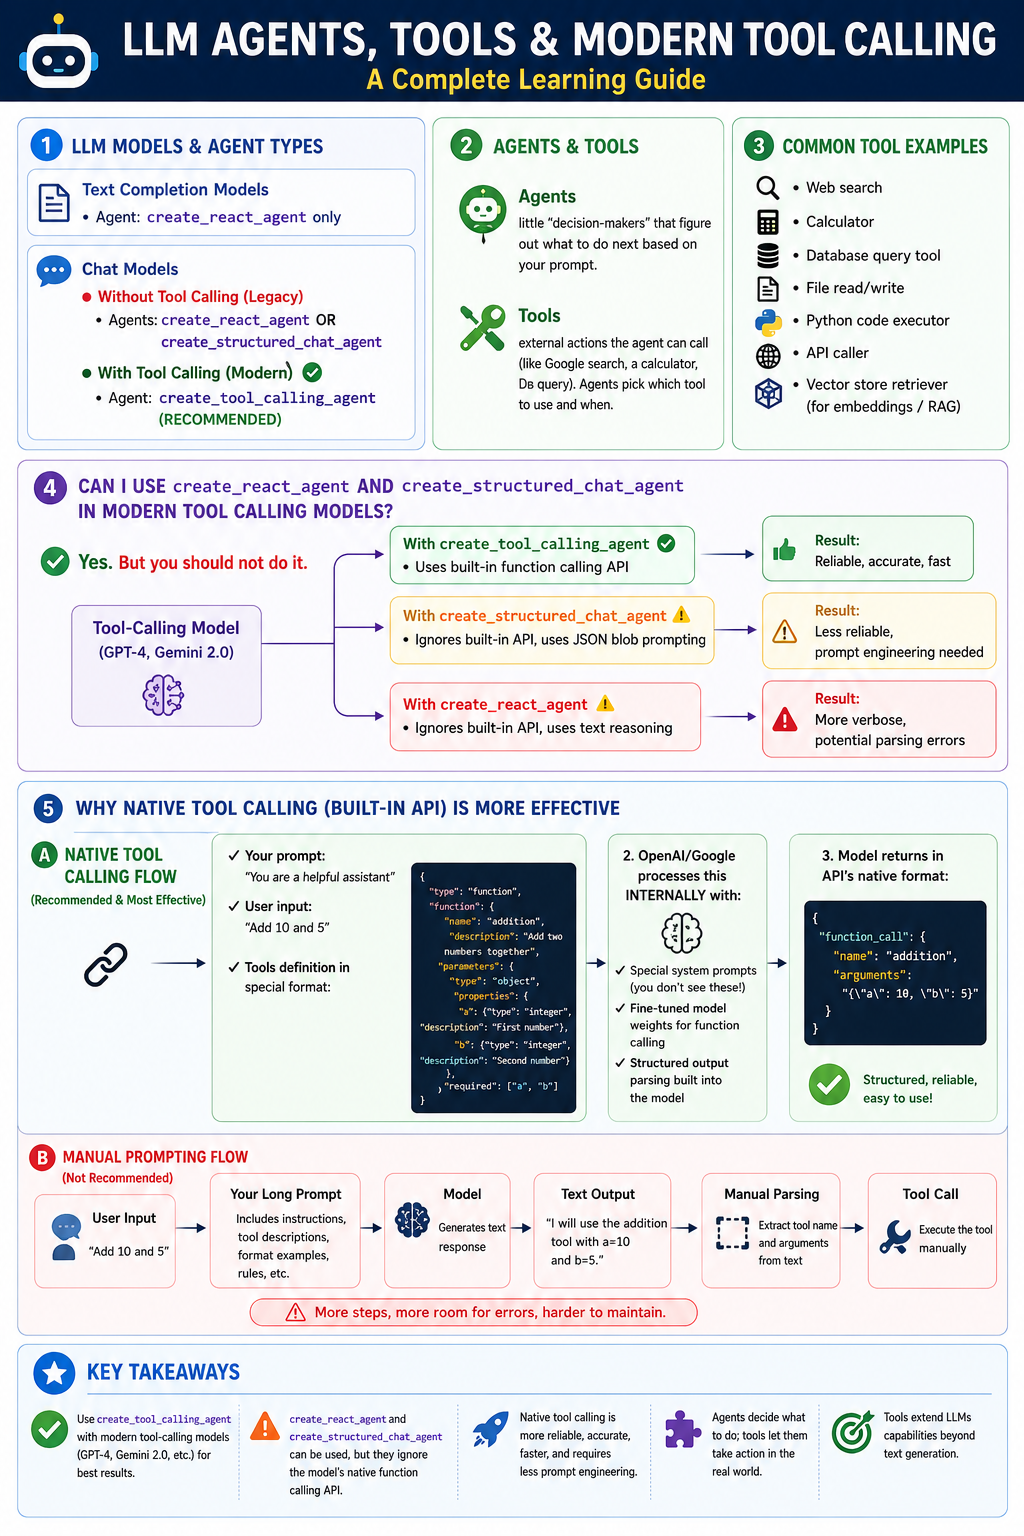
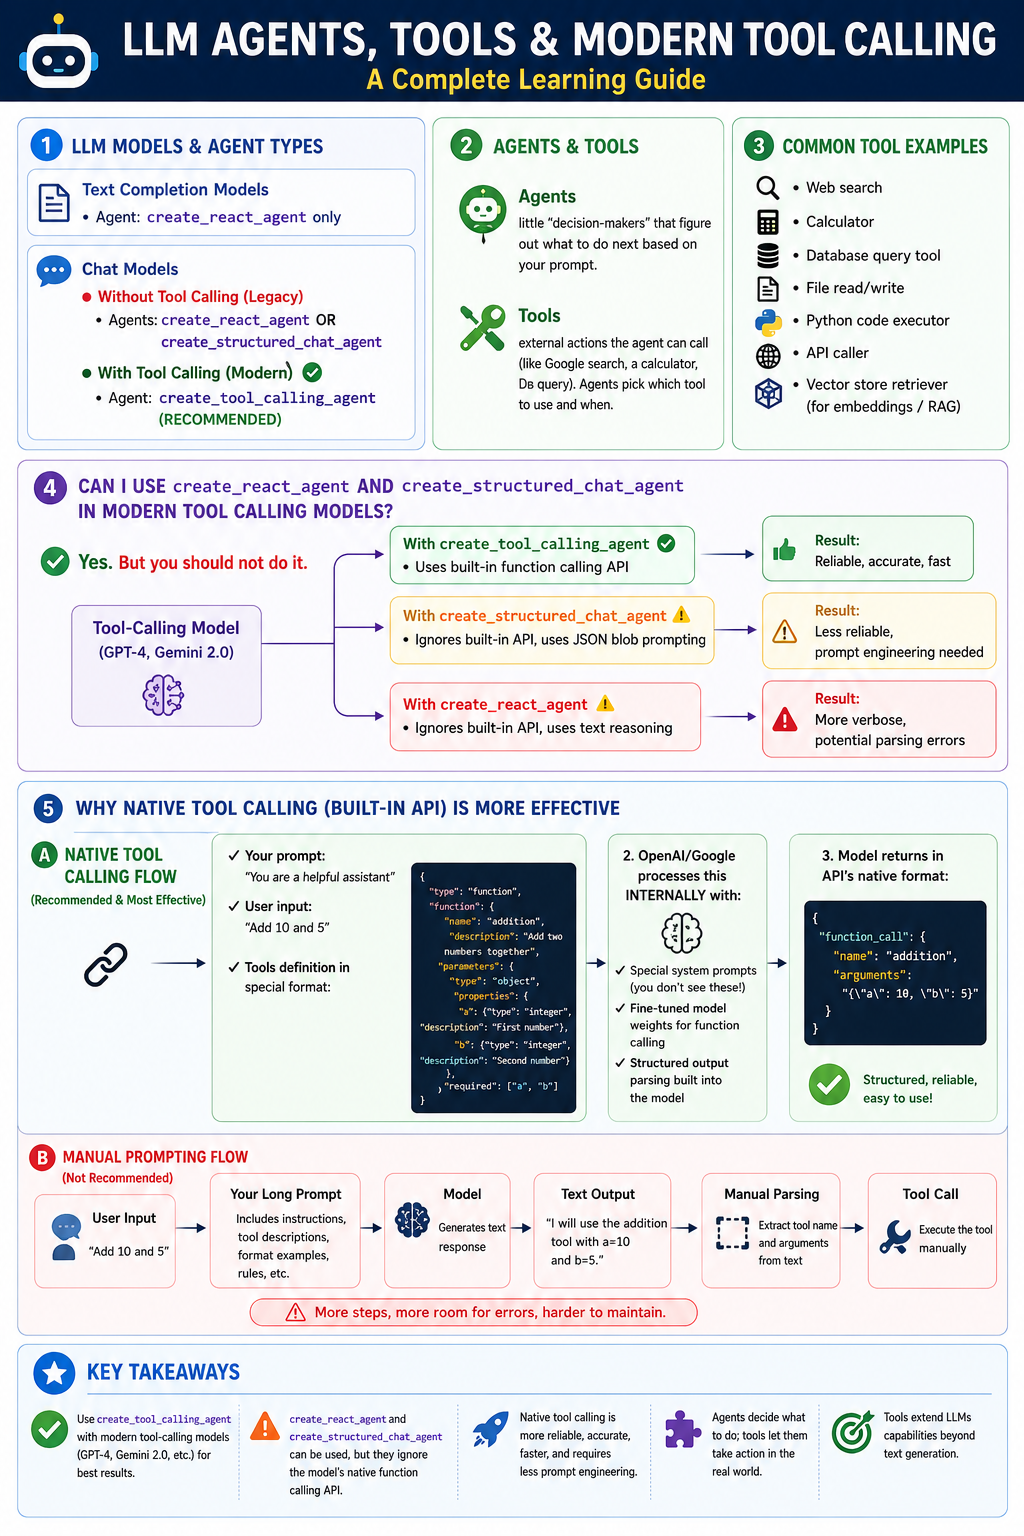

#### Try to use only create_tool_calling_agent  -> which is advance and everyone adapt to this , also other models are 

##### BoilerPlate Code

In [2]:
import langchain 
import os
from langchain_groq import ChatGroq
from langchain_core.prompts import PromptTemplate ,ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from dotenv import load_dotenv

load_dotenv()
groq_api_key=os.getenv("GROQ_API_KEY")

llm=ChatGroq(
    api_key=groq_api_key,
    model="openai/gpt-oss-120b",temperature=0.2)
llm.invoke("Hello, how are you?")

AIMessage(content="Hello! I'm doing great, thank you for asking. How can I assist you today?", additional_kwargs={'reasoning_content': 'We need to respond. The system says we are ChatGPT. The user says "Hello, how are you?" We respond politely.'}, response_metadata={'token_usage': {'completion_tokens': 55, 'prompt_tokens': 77, 'total_tokens': 132, 'completion_time': 0.114433778, 'completion_tokens_details': {'reasoning_tokens': 28}, 'prompt_time': 0.003092866, 'prompt_tokens_details': None, 'queue_time': 0.285709582, 'total_time': 0.117526644}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_5082008e34', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a0615c-8c1d-78a0-8645-7e981b1a0668-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 77, 'output_tokens': 55, 'total_tokens': 132, 'output_token_details': {'reasoning': 28}})

## create _tool_calling_agent

content which located under tools **"""   """** is ***docString*** ->   using this only llm does not  knows what is function is doing 

In [28]:
from langchain_classic.agents import create_tool_calling_agent ,AgentExecutor,tools
from langchain_core.prompts import ChatPromptTemplate

@tool
def uppercase(text:str) -> str:
    """Convert the input text to uppercase."""
    return text.upper()

@tool
def generate_content (text:str) -> str:
    """Generate content based on the input text."""
    return llm.invoke(text)

@tool
def multiplication (a:int ,b:int)->int:
    """Multiply two numbers."""
    return a*b

tools=[uppercase,generate_content,multiplication]
prompt=ChatPromptTemplate.from_messages([
    ('system',"You are a helpful assistant." ),
    ('human',"{input}"),
    ("placeholder","{agent_scratchpad}"),
    ])

agent=create_tool_calling_agent(llm,tools,prompt)
agent_executor=AgentExecutor(agent=agent,tools=tools,verbose=True)
result=agent_executor.invoke({"input": "Please convert 'Joe harson' to uppercase, generate content based on 'AI is the future', and multiply 5 and 10."})



> Entering new AgentExecutor chain...

Invoking: `uppercase` with `{'text': 'Joe harson'}`


JOE HARSON
Invoking: `generate_content` with `{'text': 'AI is the future'}`


content='Absolutely—AI is shaping up to be one of the most transformative forces of our time. From healthcare and climate science to education, entertainment, and everyday productivity, intelligent systems are already helping us solve problems that were once out of reach.\n\nHere are a few areas where AI’s impact is especially exciting:\n\n| Domain | Current AI Contributions | What the Future Might Hold |\n|--------|--------------------------|----------------------------|\n| **Healthcare** | Early disease detection (e.g., radiology AI), drug discovery acceleration, personalized treatment plans | Fully integrated “digital twins” of patients, real‑time health monitoring via wearables, AI‑guided surgeries with sub‑millimeter precision |\n| **Climate & Environment** | Predictive modeling for extreme weather, optimizing 

args_schema  -> this is optional part, which is providing descreption of which type of argument this is , which used to defining for complex argument

In [34]:
from pydantic import BaseModel, Field

class AdditionInput(BaseModel):
    a: int = Field(description="First number")
    b: int = Field(description="Second number")

#@tool("addition", args_schema=AdditionInput)
def addition_func(a: int, b: int) -> int:
    return a + b

##### other way to define tools using StructuredTool
from langchain_core.tools import StructuredTool
addition = StructuredTool(
    name="addition",
    description="Add two numbers together",
    func=addition_func,
    args_schema=AdditionInput
)


#### Try to use only create_tool_calling_agent  -> which is advance and everyone adapt to this , also other models are 

### create_structured_chat_agent

- Works on google_llm but iterates over and over for openai_llm.
- Only use this if the chat model don't support native tool calling

In [37]:
from langchain_classic.agents import create_structured_chat_agent, AgentExecutor, tool
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from pydantic import BaseModel, Field

# Define input schema for structured agent
class AdditionInput(BaseModel):
    a: int = Field(description="First number to add")
    b: int = Field(description="Second number to add")

@tool("addition", args_schema=AdditionInput)
def addition(a: int, b: int) -> int:
    """Add two numbers together"""
    return a + b

tools = [addition]

prompt = ChatPromptTemplate.from_messages([
    ("system", """Respond to the human as helpfully and accurately as possible. You have access to the following tools:

{tools}

Use a json blob to specify a tool by providing an action key (tool name) and an action_input key (tool input).

Valid "action" values: "Final Answer" or {tool_names}

Provide only ONE action per $JSON_BLOB, as shown:

```
{{
  "action": $TOOL_NAME,
  "action_input": $INPUT
}}
```

Follow this format:

Question: the input question you must answer
Thought: you should always think about what to do
Action:
```
$JSON_BLOB
```
Observation: the result of the action
... (this Thought/Action/Action Input/Observation can repeat N times)
Thought: I now know the final answer
Action:
```
{{
  "action": "Final Answer",
  "action_input": "Final answer to the original input question"
}}
```

Begin!

{agent_scratchpad}"""),
    ("human", "{input}"),
])
# ⬆️ agent scratchpad is a reserved keyword

agent = create_structured_chat_agent(llm, tools, prompt)

agent_executor = AgentExecutor(
    agent=agent,
    tools=tools,
    verbose=True,
    handle_parsing_errors=True,
    max_iterations=5
)

res = agent_executor.invoke({"input": "Add 10 and 5"})
print(res)



> Entering new AgentExecutor chain...
Could not parse LLM output: 
For troubleshooting, visit: https://docs.langchain.com/oss/python/langchain/errors/OUTPUT_PARSING_FAILURE Invalid or incomplete responseCould not parse LLM output: 
For troubleshooting, visit: https://docs.langchain.com/oss/python/langchain/errors/OUTPUT_PARSING_FAILURE Invalid or incomplete responseCould not parse LLM output: 
For troubleshooting, visit: https://docs.langchain.com/oss/python/langchain/errors/OUTPUT_PARSING_FAILURE Invalid or incomplete responseCould not parse LLM output: 
For troubleshooting, visit: https://docs.langchain.com/oss/python/langchain/errors/OUTPUT_PARSING_FAILURE Invalid or incomplete responseCould not parse LLM output: 
For troubleshooting, visit: https://docs.langchain.com/oss/python/langchain/errors/OUTPUT_PARSING_FAILURE Invalid or incomplete response

> Finished chain.
{'input': 'Add 10 and 5', 'output': 'Agent stopped due to iteration limit or time limit.'}
